In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.shape

(1338, 7)

In [4]:
df.describe()
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1. check if our data is skewed or not 

In [5]:
df['sex'].unique()

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

<Axes: xlabel='charges', ylabel='Count'>

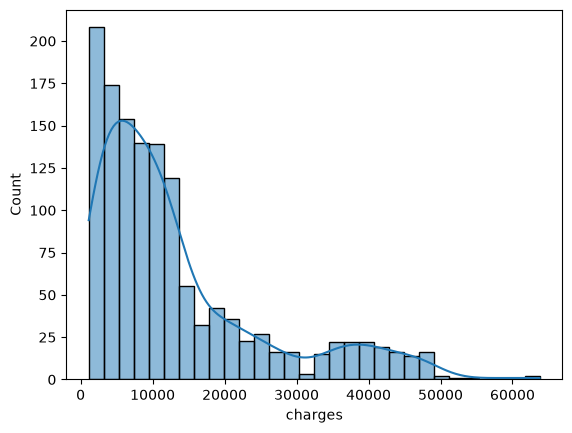

In [6]:
df['charges'].skew()
sns.histplot(df['charges'],kde = True)

<Axes: xlabel='bmi', ylabel='charges'>

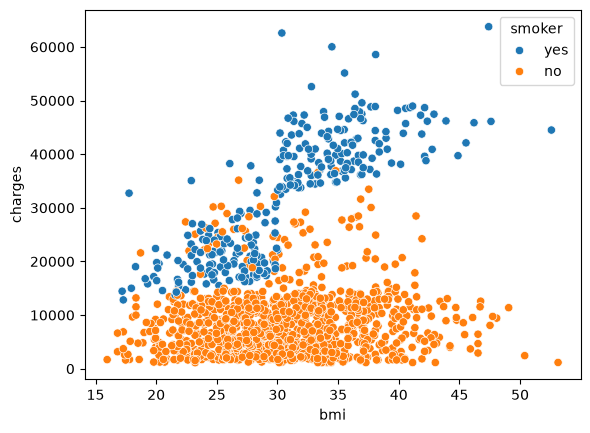

In [7]:
sns.scatterplot(x = 'bmi',y = 'charges', hue = 'smoker', data=df)

<Axes: xlabel='smoker', ylabel='charges'>

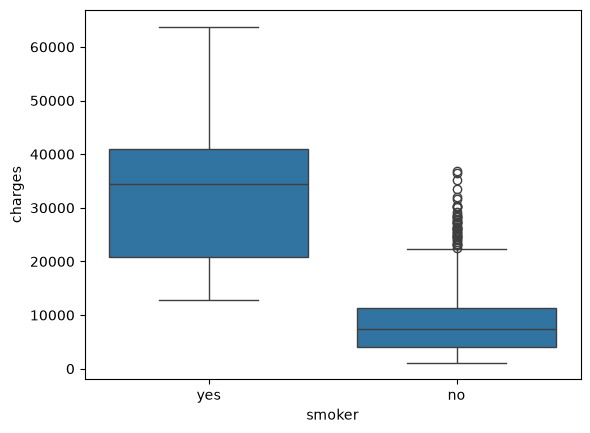

In [8]:
sns.boxplot(x='smoker', y='charges',data=df)

<Axes: >

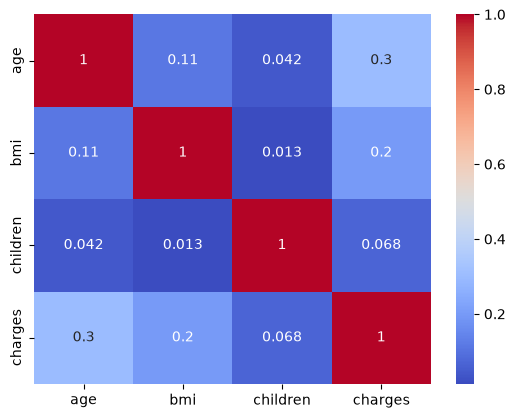

In [9]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap='coolwarm')

In [10]:
X = df.drop(columns = ['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [11]:
numeric_cols = ['age','bmi']
categorical_cols = ['smoker','sex','region']

In [12]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [13]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [14]:
models_and_params = {
    'LinearRegression': (LinearRegression(), {}),
    'Ridge': (Ridge(), {'regressor__alpha': [0.1, 1, 10, 100]}),
    'Lasso': (Lasso(), {'regressor__alpha': [0.01, 0.1, 1, 10]}),
    'DecisionTree': (DecisionTreeRegressor(random_state=42),
                      {'regressor__max_depth': [3, 5, 10, None],
                       'regressor__min_samples_split': [2, 5, 10]}),
    'RandomForest': (RandomForestRegressor(random_state=42),
                      {'regressor__n_estimators': [100, 200],
                       'regressor__max_depth': [5, 10, None]}),
}

In [15]:
results = {}
best_estimators = {}

for name, (model, param_grid) in models_and_params.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    grid = GridSearchCV(pipe, param_grid, cv=5,
                         scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    
    results[name] = {
        'best_score_cv': grid.best_score_,
        'best_params': grid.best_params_,
        'test_r2': grid.score(X_test, y_test)
    }


In [16]:
for name, res in results.items():
    print(name, res)
    print('-' *100)

LinearRegression {'best_score_cv': np.float64(0.7314112574759507), 'best_params': {}, 'test_r2': 0.7800795892260541}
----------------------------------------------------------------------------------------------------
Ridge {'best_score_cv': np.float64(0.7314523304315426), 'best_params': {'regressor__alpha': 1}, 'test_r2': 0.7797826613297876}
----------------------------------------------------------------------------------------------------
Lasso {'best_score_cv': np.float64(0.7315998604179323), 'best_params': {'regressor__alpha': 10}, 'test_r2': 0.7796412548897813}
----------------------------------------------------------------------------------------------------
DecisionTree {'best_score_cv': np.float64(0.8405906791361915), 'best_params': {'regressor__max_depth': 3, 'regressor__min_samples_split': 2}, 'test_r2': 0.8530572866320028}
----------------------------------------------------------------------------------------------------
RandomForest {'best_score_cv': np.float64(0.8421512

In [17]:
eval_results = []

for name, model in best_estimators.items():
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    eval_results.append({
        'Model': name,
        'Train R²': round(r2_score(y_train, y_pred_train), 4),
        'Test R²':  round(r2_score(y_test,  y_pred_test),  4),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)':  round(cv_scores.std(),  4),
        'Test MAE':  round(mean_absolute_error(y_test, y_pred_test), 2),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)
    })

results_df = pd.DataFrame(eval_results).set_index('Model')
print(results_df.to_string())


                  Train R²  Test R²  CV R² (mean)  CV R² (std)  Test MAE  Test RMSE
Model                                                                              
LinearRegression    0.7399   0.7801        0.7449       0.0238   4222.91    5843.15
Ridge               0.7399   0.7798        0.7449       0.0235   4235.49    5847.09
Lasso               0.7398   0.7796        0.7450       0.0235   4231.60    5848.97
DecisionTree        0.8537   0.8531        0.8445       0.0368   2865.64    4776.26
RandomForest        0.8810   0.8653        0.8520       0.0335   2673.61    4572.65


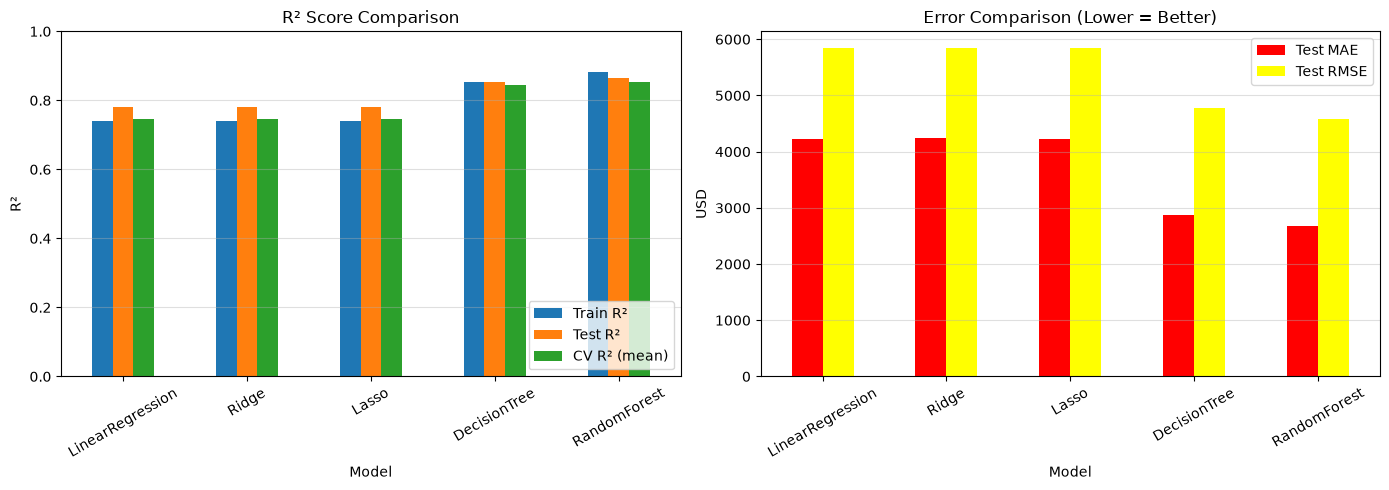

In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Train R²', 'Test R²', 'CV R² (mean)']].plot(kind='bar', ax=axes[0], rot=30)
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.4)

results_df[['Test MAE', 'Test RMSE']].plot(kind='bar', ax=axes[1], rot=30, color=['red', 'yellow'])
axes[1].set_title('Error Comparison (Lower = Better)')
axes[1].set_ylabel('USD')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')

best_model_name = results_df['Test R²'].idxmax()
final_model = best_estimators[best_model_name]

print(f"Selected model: {best_model_name}")
print(results_df.loc[best_model_name])

import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)